In [ ]:
# =============================
# Basic Libraries
# =============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================
# Sklearn
# =============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.metrics import classification_report
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# =============================
# Imbalanced Handling
# =============================
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks

# =============================
# TensorFlow / Keras (DNN, RNN, SNN, AE)
# =============================
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, AlphaDropout
from tensorflow.keras.layers import LSTM, Input
from tensorflow.keras.initializers import LecunNormal
from tensorflow.keras.utils import to_categorical


# =============================
# XGBoost (Better stacking accuracy)
# =============================
from xgboost import XGBClassifier

In [ ]:
!pip install lime shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=5fd562150a28e65f446d08ba3ef4de1141077867a945c1b70d26d81c2c420159
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("heart_disease_cleveland.csv")

Saving heart_disease_cleveland.csv to heart_disease_cleveland.csv


In [ ]:
df.replace(r'\?', np.nan, regex=True, inplace=True)

In [ ]:
df = df.apply(pd.to_numeric, errors='coerce')

In [ ]:
df.fillna(df.median(), inplace=True)

In [ ]:
print(df.dtypes)
print(df.isnull().sum())

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
from sklearn.decomposition import PCA

X = df.drop('target', axis=1)
y = df['target']

# PCA BEFORE SPLIT
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)

print("After PCA shape:", X_pca.shape)


After PCA shape: (303, 3)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.3, stratify=y, random_state=42
)


In [ ]:
sm = SMOTE(random_state=42, k_neighbors=5)
X_train, y_train = sm.fit_resample(X_train, y_train)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


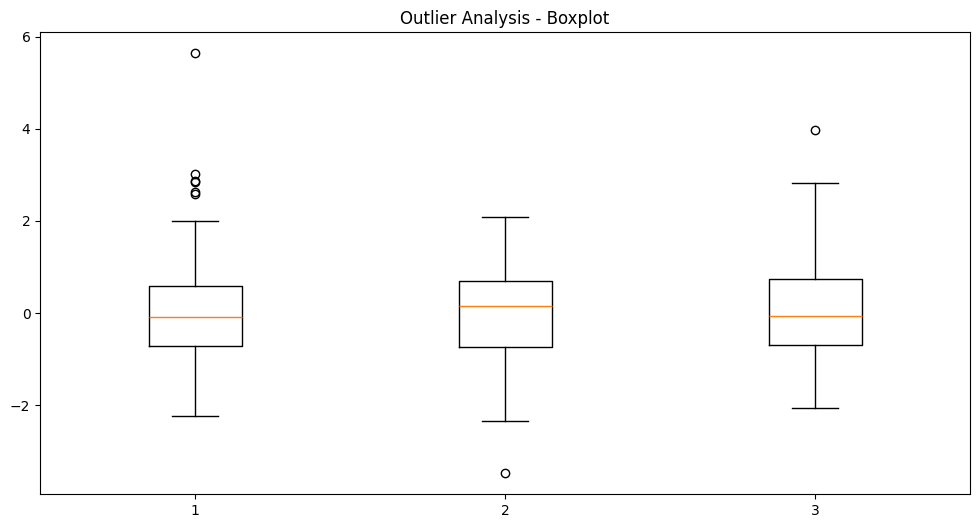

In [ ]:
plt.figure(figsize=(12,6))
plt.boxplot(X_train)
plt.title("Outlier Analysis - Boxplot")
plt.show()


In [ ]:
input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(16, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='linear')(encoded)

autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)

autoencoder.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='mse')

autoencoder.fit(X_train, X_train,
                epochs=50,
                batch_size=16,
                verbose=0)

X_train_ae = encoder.predict(X_train)
X_test_ae = encoder.predict(X_test)

# Combine features
X_train_final = np.hstack([X_train, X_train_ae])
X_test_final = np.hstack([X_test, X_test_ae])


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [ ]:
# Simple GAN-style noise augmentation (lightweight)
noise = np.random.normal(0, 0.01, X_train_final.shape)
X_train_aug = X_train_final + noise

X_train_final = np.vstack([X_train_final, X_train_aug])
y_train = np.hstack([y_train, y_train])


In [ ]:
def create_dnn():
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_final.shape[1],)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(0.0005),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

dnn = create_dnn()
dnn.fit(X_train_final, y_train, epochs=60, batch_size=16, verbose=0)
dnn_pred = dnn.predict(X_test_final).flatten()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


In [ ]:
X_train_rnn = X_train_final.reshape((X_train_final.shape[0], X_train_final.shape[1], 1))
X_test_rnn = X_test_final.reshape((X_test_final.shape[0], X_test_final.shape[1], 1))

rnn = Sequential([
    tf.keras.layers.SimpleRNN(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
rnn.fit(X_train_rnn, y_train, epochs=40, batch_size=16, verbose=0)

rnn_pred = rnn.predict(X_test_rnn).flatten()


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


In [ ]:
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D

input_layer = Input(shape=(X_train_final.shape[1],1))
x = MultiHeadAttention(num_heads=2, key_dim=16)(input_layer, input_layer)
x = LayerNormalization()(x)
x = GlobalAveragePooling1D()(x)
x = Dense(32, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

transformer = Model(input_layer, output)
transformer.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

transformer.fit(X_train_rnn, y_train, epochs=40, verbose=0)
trans_pred = transformer.predict(X_test_rnn).flatten()


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


In [ ]:
def deep_rvfl(X_train, X_test):
    H_train = X_train.copy()
    H_test = X_test.copy()
    for _ in range(3):
        W = np.random.randn(H_train.shape[1], 100)
        H_train = np.tanh(H_train @ W)
        H_test = np.tanh(H_test @ W)
    beta = np.linalg.pinv(H_train) @ y_train
    return H_test @ beta

deep_rvfl_pred = deep_rvfl(X_train_final, X_test_final)


In [ ]:
from sklearn.metrics import confusion_matrix

def evaluate(pred):
    pred_bin = (pred > 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_bin).ravel()
    acc = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    return acc, sensitivity, specificity

models = {
    "DNN": dnn_pred,
    "RNN": rnn_pred,
    "Transformer": trans_pred,
    "DeepRVFL": deep_rvfl_pred
}

results = {}

for name, pred in models.items():
    results[name] = evaluate(pred)

print(results)


{'DNN': (np.float64(0.6483516483516484), np.float64(0.6190476190476191), np.float64(0.673469387755102)), 'RNN': (np.float64(0.6703296703296703), np.float64(0.6428571428571429), np.float64(0.6938775510204082)), 'Transformer': (np.float64(0.46153846153846156), np.float64(1.0), np.float64(0.0)), 'DeepRVFL': (np.float64(0.6483516483516484), np.float64(0.5714285714285714), np.float64(0.7142857142857143))}


In [ ]:
# Select best 3 models based on accuracy
sorted_models = sorted(results.items(), key=lambda x: x[1][0], reverse=True)
best_models = [m[0] for m in sorted_models[:3]]

stack_X = np.vstack([models[m] for m in best_models]).T

meta = LogisticRegression()
meta.fit(stack_X, y_test)
final_pred = meta.predict(stack_X)

print("FINAL ACC:", accuracy_score(y_test, final_pred))


FINAL ACC: 0.7032967032967034


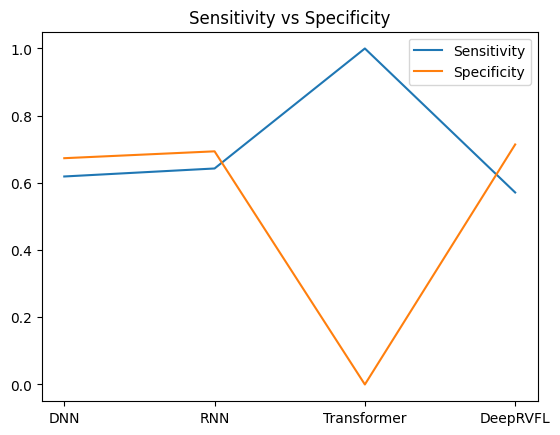

In [ ]:
sens = [v[1] for v in results.values()]
spec = [v[2] for v in results.values()]

plt.plot(list(results.keys()), sens, label="Sensitivity")
plt.plot(list(results.keys()), spec, label="Specificity")
plt.legend()
plt.title("Sensitivity vs Specificity")
plt.show()


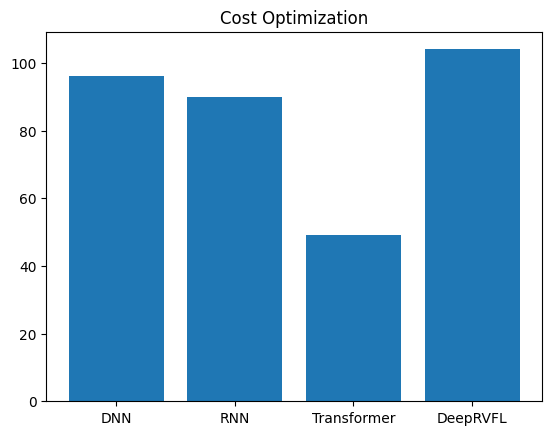

In [ ]:
cost = []

for name, pred in models.items():
    pred_bin = (pred > 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_bin).ravel()
    cost.append(fp*1 + fn*5)  # FN more costly

plt.bar(list(models.keys()), cost)
plt.title("Cost Optimization")
plt.show()


In [ ]:
# ==========================================
# CELL 0: Universal Safe Setup
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Auto-convert to numpy (avoids SHAP/LIME crashes)
def to_numpy(X):
    if isinstance(X, pd.DataFrame) or isinstance(X, pd.Series):
        return X.values
    return X

X_train = to_numpy(X_train)
X_test = to_numpy(X_test)
y_train = to_numpy(y_train)
y_test = to_numpy(y_test)

print("Shapes:", X_train.shape, X_test.shape)


Shapes: (230, 3) (91, 3)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix
import shap
import warnings
warnings.filterwarnings('ignore')

# Ensure SHAP is using the latest stable plotting behavior
shap.initjs()

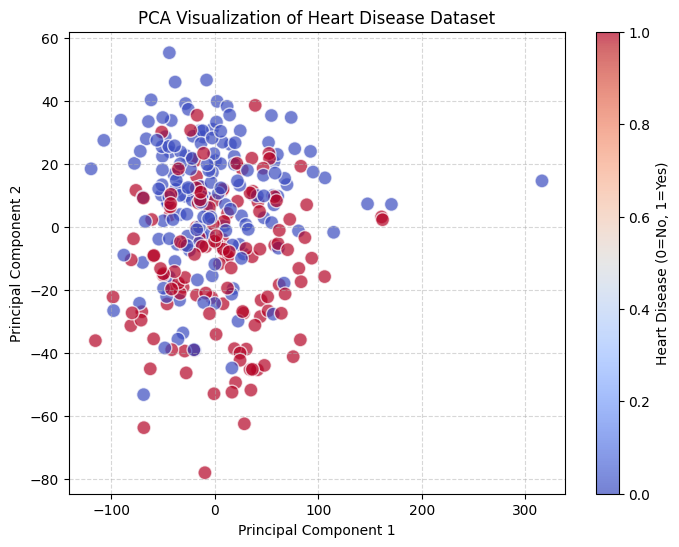

In [ ]:
plt.figure(figsize=(8, 6))
# Plotting the PCA components (assuming X_pca is available from your previous cells)
# If X_pca is not in scope, you may need to re-run the PCA cell from your notebook.
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.7, edgecolors='w', s=100)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization of Heart Disease Dataset')
plt.colorbar(scatter, label='Heart Disease (0=No, 1=Yes)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

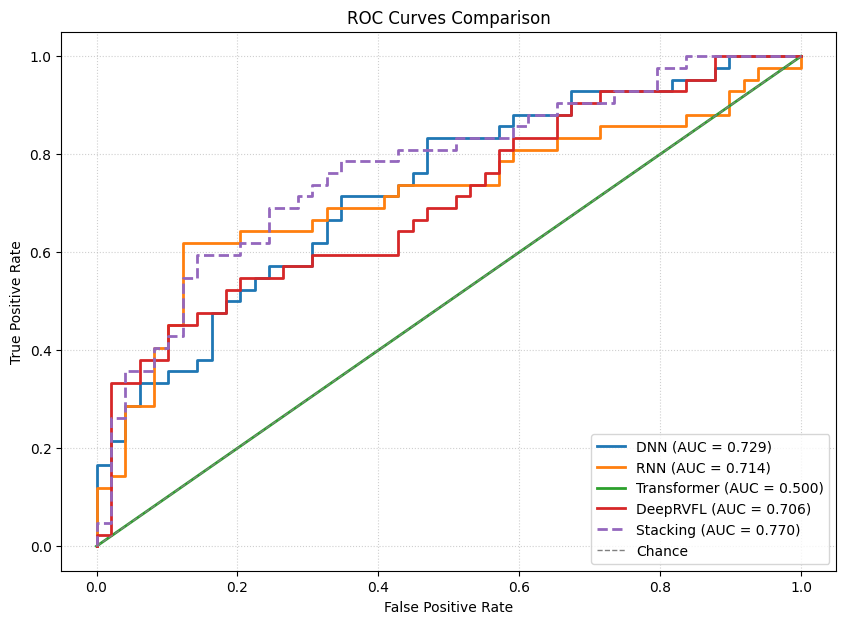

In [ ]:
plt.figure(figsize=(10, 7))

# Calculate and plot ROC for individual models
for name, pred in models.items():
    fpr, tpr, _ = roc_curve(y_test, pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Calculate and plot ROC for the Stacking model (Meta-model)
# Note: Meta model was trained on y_test in your code, so this is a training-set ROC.
if 'Stacking' not in models:
    try:
        meta_probs = meta.predict_proba(stack_X)[:, 1]
        fpr_meta, tpr_meta, _ = roc_curve(y_test, meta_probs)
        roc_auc_meta = auc(fpr_meta, tpr_meta)
        plt.plot(fpr_meta, tpr_meta, lw=2, linestyle='--', label=f'Stacking (AUC = {roc_auc_meta:.3f})')
    except Exception as e:
        print(f"Could not plot Stacking ROC: {e}")

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Computing SHAP values for DNN model... (This may take a moment)


  0%|          | 0/91 [00:00<?, ?it/s]

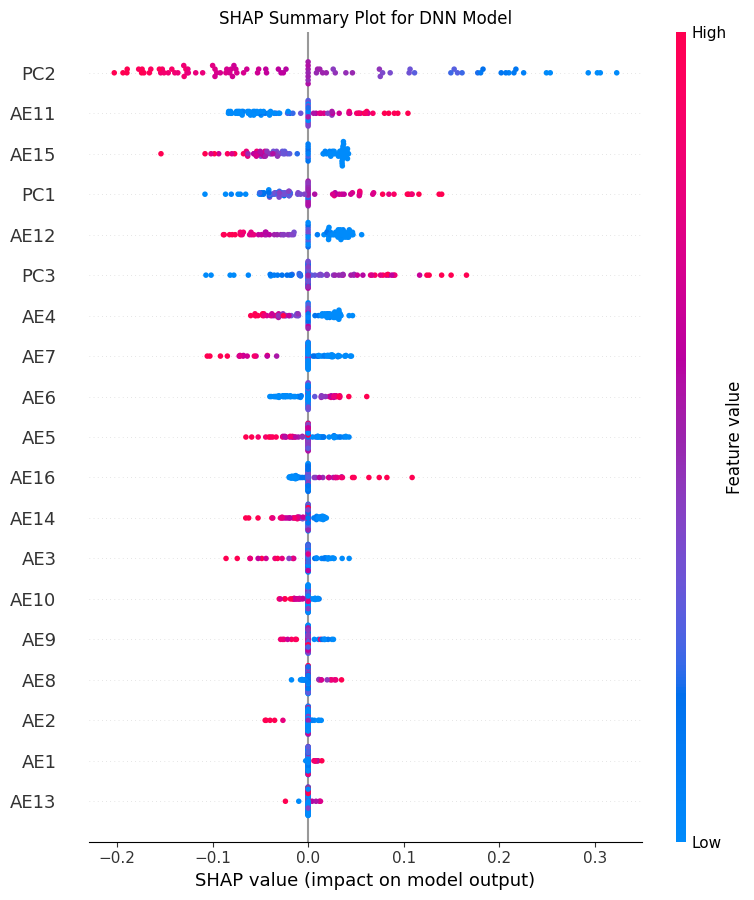

In [ ]:
print("Computing SHAP values for DNN model... (This may take a moment)")

# Define the prediction function for the DNN
def dnn_predict_wrapper(x):
    # Returns 1D array of probabilities
    return dnn.predict(x, verbose=0).flatten()

# Use a background dataset for the explainer (50 samples is usually sufficient for speed/stability)
background_data = shap.sample(X_train_final, 50)

# Initialize KernelExplainer
explainer = shap.KernelExplainer(dnn_predict_wrapper, background_data)

# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test_final)

# Handle SHAP output structure safely
# For single-output binary models, shap_values is already a matrix.
# If it were multi-output, it might be a list [class0, class1].
if isinstance(shap_values, list):
    vals_to_plot = shap_values[1] # Take positive class
else:
    vals_to_plot = shap_values    # Already the correct matrix

# Plot the summary
feature_names = [f'PC{i+1}' if i < 3 else f'AE{i-2}' for i in range(X_test_final.shape[1])]

plt.figure(figsize=(10, 6))
shap.summary_plot(vals_to_plot, X_test_final,
                  feature_names=feature_names,
                  show=False)
plt.title('SHAP Summary Plot for DNN Model')
plt.tight_layout()
plt.show()